In [1]:
# Uncomment the next line if numpy / matplotlib / pandas are not installed.
# !pip install numpy matplotlib pandas

import importlib, sys
for pkg in ("numpy", "matplotlib", "pandas"):
    print(f"{pkg:12s}", "OK" if importlib.util.find_spec(pkg) else "MISSING  -> run the pip line above")
print("python      ", sys.version.split()[0])

numpy        OK
matplotlib   OK
pandas       OK
python       3.13.9


In [2]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 300, "font.size": 11})

RESULTS_DIR = "simulation_results_final"
os.makedirs(RESULTS_DIR, exist_ok=True)

QUICK_RUN = False          # True -> fewer seeds / GRAPE iterations (fast check)
N_SEEDS   = 5 if QUICK_RUN else 30
GRAPE_IT  = 12 if QUICK_RUN else 40

# ---- time grid ----
T, dt = 10.0, 1.0e-3
N     = int(round(T / dt)) + 1
tgrid = np.linspace(0.0, T, N)

print(f"horizon T = {T},  step dt = {dt},  grid points N = {N}")
print(f"QUICK_RUN = {QUICK_RUN}  (seeds = {N_SEEDS}, GRAPE iterations = {GRAPE_IT})")
print("output folder:", os.path.abspath(RESULTS_DIR))

horizon T = 10.0,  step dt = 0.001,  grid points N = 10001
QUICK_RUN = False  (seeds = 30, GRAPE iterations = 40)
output folder: C:\Users\vijay\PC Python files\FTSY and OC for QTDS\July 2026\simulation_results_final


In [3]:
A0 = np.array([[-2j, 0.0], [0.0,  2j ]], dtype=complex)   
A1 = np.array([[0.0, -2.14], [2.14, 0.0]], dtype=complex) 
Ad = np.array([[-0.05j, 0.0], [0.0, 0.05j]], dtype=complex)  

z0 = np.array([1.0 + 0j, 0.0 + 0j])   
zr = np.array([0.0 + 0j, 1.0 + 0j])   

Qc        = np.eye(2)     
R_DEFAULT = 0.25          
VSAT      = 5.0           
K_BASE    = 6.0           
K_ADM     = 4.0           

# structural checks
print("A0 anti-Hermitian:", np.allclose(A0.conj().T, -A0))
print("A1 anti-Hermitian:", np.allclose(A1.conj().T, -A1))
print("Ad anti-Hermitian:", np.allclose(Ad.conj().T, -Ad))

A0 anti-Hermitian: True
A1 anti-Hermitian: True
Ad anti-Hermitian: True


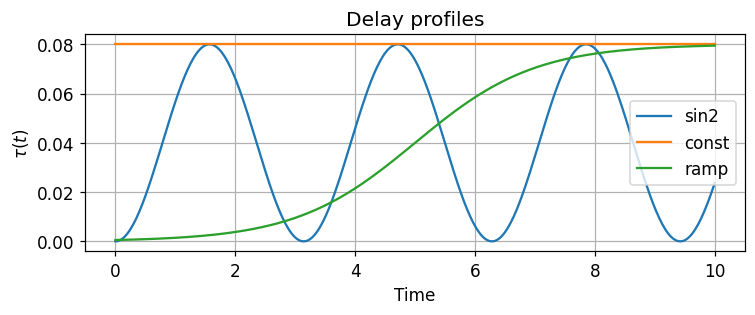

In [4]:
def tau_sin2(t, tmax=0.08):  return tmax * np.sin(t) ** 2                      
def tau_const(t, tmax=0.08): return tmax + 0.0 * np.asarray(t)                 
def tau_ramp(t, tmax=0.08):  return tmax * (0.5 + 0.5*np.tanh(0.5*(t - 5.0)))  

DELAY_PROFILES = {"sin2": tau_sin2, "const": tau_const, "ramp": tau_ramp}

_t = np.linspace(0, T, 400)
plt.figure(figsize=(7,3))
for nm, fn in DELAY_PROFILES.items():
    plt.plot(_t, fn(_t), label=nm)
plt.xlabel("Time"); plt.ylabel(r"$\tau(t)$"); plt.legend(); plt.grid(True)
plt.title("Delay profiles"); plt.tight_layout(); plt.show()

In [5]:
def W_complex(t):
    return np.array([[1.0, 0.0], [0.0, 1.0 + 0.03*t]], dtype=complex)

P_MAT = 0.5 * np.eye(2)
print("W(0) =\n", np.real(W_complex(0.0)), "\n\nW(T) =\n", np.real(W_complex(T)))

W(0) =
 [[1. 0.]
 [0. 1.]] 

W(T) =
 [[1.  0. ]
 [0.  1.3]]


In [6]:
def real_rep(M):
    Mr, Mi = np.real(M), np.imag(M)
    return np.block([[Mr, -Mi], [Mi, Mr]])

A0r, A1r, Adr = real_rep(A0), real_rep(A1), real_rep(Ad)

def c2r(z):                      return np.concatenate([np.real(z), np.imag(z)])   # C^2 -> R^4
def augmented_state(z_now, z_del): return np.concatenate([c2r(z_now), c2r(z_del)]) # -> R^8

_z = np.array([0.3+0.4j, -0.5+0.2j])
print("norm preserved      :", np.allclose(np.linalg.norm(A1 @ _z), np.linalg.norm(A1r @ c2r(_z))))
print("R(A0 A1) = R(A0)R(A1):", np.allclose(real_rep(A0 @ A1), A0r @ A1r))

norm preserved      : True
R(A0 A1) = R(A0)R(A1): True


In [7]:
TANH_A = 1.5

def basis(zeta):
    return np.concatenate([[1.0], zeta, zeta**2, np.tanh(TANH_A*zeta), np.sin(zeta)])

def basis_grad(zeta):
    # Analytic Jacobian d(phi)/d(zeta), shape (N_basis, 8)
    n = zeta.size
    G = np.zeros((1 + 4*n, n))
    G[1:1+n, :]       = np.eye(n)                                        
    G[1+n:1+2*n, :]   = np.diag(2.0*zeta)                                
    G[1+2*n:1+3*n, :] = np.diag(TANH_A*(1.0 - np.tanh(TANH_A*zeta)**2))  
    G[1+3*n:1+4*n, :] = np.diag(np.cos(zeta))                            
    return G

NB = basis(np.zeros(8)).size
print("basis dimension  N_c = N_a =", NB)

_z = np.random.default_rng(0).standard_normal(8)*0.5
G_an = basis_grad(_z); G_fd = np.zeros_like(G_an); h = 1e-6
for j in range(8):
    e = np.zeros(8); e[j] = h
    G_fd[:, j] = (basis(_z+e) - basis(_z-e)) / (2*h)
print("max |analytic - finite difference| =", np.max(np.abs(G_an - G_fd)))

basis dimension  N_c = N_a = 33
max |analytic - finite difference| = 4.038780421211641e-11


In [8]:
def f_cont(z, z_del, v):
    return (A0 + v*A1) @ z + Ad @ z_del

def rk4_step(z, z_del, v):
    k1 = f_cont(z,              z_del, v)
    k2 = f_cont(z + 0.5*dt*k1,  z_del, v)
    k3 = f_cont(z + 0.5*dt*k2,  z_del, v)
    k4 = f_cont(z + dt*k3,      z_del, v)
    return z + dt/6.0*(k1 + 2*k2 + 2*k3 + k4)

def get_delayed_state(z_hist, k, tau_t):
    tq = tgrid[k] - tau_t
    if tq <= 0.0: return z0.copy()
    idx = int(np.searchsorted(tgrid[:k+1], tq))
    if idx <= 0:  return z_hist[0].copy()
    if idx > k:   return z_hist[k].copy()
    t1, t2 = tgrid[idx-1], tgrid[idx]
    a = (tq - t1) / (t2 - t1 + 1e-12)
    return (1.0 - a)*z_hist[idx-1] + a*z_hist[idx]

_ztest = z0.copy()
for _ in range(2000):
    _ztest = _ztest + dt/6.0*( (A0@_ztest) + 2*(A0@(_ztest+0.5*dt*(A0@_ztest)))
                             + 2*(A0@(_ztest+0.5*dt*(A0@_ztest))) + (A0@(_ztest+dt*(A0@_ztest))) )
print("RK4 norm drift over 2000 steps (undriven, no delay): %.3e" % abs(np.linalg.norm(_ztest)-1))

RK4 norm drift over 2000 steps (undriven, no delay): 4.000e-09


In [9]:
def tracking_error(z): return float(np.linalg.norm(z - zr))

def fidelity(z):
    num = np.abs(np.vdot(zr, z))**2
    den = (np.linalg.norm(zr)**2)*(np.linalg.norm(z)**2) + 1e-12
    return float(np.real(num/den))

def infidelity(z):  return 1.0 - fidelity(z)
def state_norm(z):  return float(np.real(np.vdot(z, z)))

def reach_time(fid_arr, thr=0.95):
    above = np.where(fid_arr >= thr)[0]
    return float(tgrid[above[0]]) if above.size else np.nan

def settling_time(fid_arr, thr=0.95):
    below = np.where(fid_arr < thr)[0]
    if below.size == 0: return 0.0
    last = below[-1]
    return np.nan if last >= N-1 else float(tgrid[last+1])

def lkf_value(z_hist, k, tau_t):
      t, z = tgrid[k], z_hist[k]
    term1 = float(np.real(np.conjugate(z) @ (W_complex(t) @ z)))
    tq   = max(t - tau_t, 0.0)
    idx0 = max(int(np.searchsorted(tgrid[:k+1], tq)), 0)
    integ = 0.0
    for j in range(idx0, k):
        fj  = float(np.real(np.conjugate(z_hist[j])   @ (P_MAT @ z_hist[j])))
        fj1 = float(np.real(np.conjugate(z_hist[j+1]) @ (P_MAT @ z_hist[j+1])))
        integ += 0.5*(fj + fj1)*dt
    return term1 + integ

print("metrics defined")

metrics defined


In [10]:
def lyapunov_control(z, k=K_BASE):
    return float(np.clip(-k*np.imag(np.vdot(zr, A1 @ z)), -VSAT, VSAT))

def simulate_lyapunov(tau_func=tau_sin2, tmax=0.08, R=R_DEFAULT, k=K_BASE):
    z = np.zeros((N,2), complex); z[0] = z0.copy()
    u=np.zeros(N); err=np.zeros(N); fid=np.zeros(N); nrm=np.zeros(N); en=np.zeros(N)
    for kk in range(N-1):
        zd = get_delayed_state(z, kk, tau_func(tgrid[kk], tmax))
        v  = lyapunov_control(z[kk], k)
        z[kk+1] = rk4_step(z[kk], zd, v)
        u[kk]=v; err[kk]=tracking_error(z[kk]); fid[kk]=fidelity(z[kk]); nrm[kk]=state_norm(z[kk])
        en[kk] = (en[kk-1] if kk>0 else 0.0) + dt*v*v
    u[-1]=u[-2]; err[-1]=tracking_error(z[-1]); fid[-1]=fidelity(z[-1])
    nrm[-1]=state_norm(z[-1]); en[-1]=en[-2]
    return dict(z=z,u=u,err=err,fid=fid,norm=nrm,energy=en)

print("Lyapunov baseline defined")

Lyapunov baseline defined


In [11]:
def rollout_pwc(vp, tau_func=tau_sin2, tmax=0.08):
    M = vp.size; seg = N//M
    z = np.zeros((N,2), complex); z[0]=z0.copy(); u=np.zeros(N)
    for kk in range(N-1):
        v  = float(np.clip(vp[min(kk//seg, M-1)], -VSAT, VSAT))
        zd = get_delayed_state(z, kk, tau_func(tgrid[kk], tmax))
        z[kk+1] = rk4_step(z[kk], zd, v); u[kk]=v
    u[-1]=u[-2]
    return z, u

def rollout_pwc_coarse(vp, tau_func, tmax, Nc, tc, dtc):
    M = vp.size; seg = Nc//M
    z = np.zeros((Nc,2), complex); z[0]=z0.copy()
    for kk in range(Nc-1):
        v  = float(np.clip(vp[min(kk//seg, M-1)], -VSAT, VSAT))
        tq = tc[kk] - tau_func(tc[kk], tmax)
        if tq <= 0: zd = z0.copy()
        else:
            idx = int(np.searchsorted(tc[:kk+1], tq)); idx = min(max(idx,1), kk)
            a   = (tq - tc[idx-1])/(tc[idx]-tc[idx-1]+1e-12)
            zd  = (1-a)*z[idx-1] + a*z[idx]
        k1=f_cont(z[kk],zd,v);              k2=f_cont(z[kk]+0.5*dtc*k1,zd,v)
        k3=f_cont(z[kk]+0.5*dtc*k2,zd,v);   k4=f_cont(z[kk]+dtc*k3,zd,v)
        z[kk+1] = z[kk] + dtc/6.0*(k1+2*k2+2*k3+k4)
    return z

def simulate_grape(tau_func=tau_sin2, tmax=0.08, R=R_DEFAULT, M=15, iters=None, lr=0.5, seed=0):
    iters = GRAPE_IT if iters is None else iters
    Nc = 800; tc = np.linspace(0.0, T, Nc); dtc = tc[1]-tc[0]
    rng = np.random.default_rng(seed); vp = 0.3*rng.standard_normal(M)

    def Jc(v):                                   
        z = rollout_pwc_coarse(v, tau_func, tmax, Nc, tc, dtc)
        return -fidelity(z[-1])

    base = Jc(vp); eps = 1e-3
    for _ in range(iters):                       
        g = np.zeros(M)
        for m in range(M):
            vpp = vp.copy(); vpp[m] += eps
            g[m] = (Jc(vpp) - base)/eps
        vp -= lr*g; base = Jc(vp)

    z, u = rollout_pwc(vp, tau_func, tmax)       # report on the fine grid
    err = np.array([tracking_error(z[i]) for i in range(N)])
    fid = np.array([fidelity(z[i])        for i in range(N)])
    nrm = np.array([state_norm(z[i])      for i in range(N)])
    en  = np.cumsum(u**2)*dt
    return dict(z=z,u=u,err=err,fid=fid,norm=nrm,energy=en)

print("GRAPE benchmark defined")

GRAPE benchmark defined


In [12]:
def init_admissible_actor(seed=0, k=K_ADM, n_samples=700, lam=0.5):
    # Regularized least-squares projection of the admissible Lyapunov policy onto the basis
    rng = np.random.default_rng(seed); Phi=[]; y=[]
    for _ in range(n_samples):
        zz = z0 + 0.8*(rng.standard_normal(2) + 1j*rng.standard_normal(2))
        zz = zz/(np.linalg.norm(zz) + 1e-9)
        zd = zz + 0.05*(rng.standard_normal(2) + 1j*rng.standard_normal(2))
        Phi.append(basis(augmented_state(zz, zd)))
        y.append(lyapunov_control(zz, k))
    Phi = np.array(Phi); y = np.array(y)
    return np.linalg.solve(Phi.T@Phi + lam*np.eye(NB), Phi.T@y)


def simulate_actor_critic(tau_func=tau_sin2, tmax=0.08, R=R_DEFAULT,
                          gamma_c=0.02, gamma_a=0.015, seed=0, k=K_ADM,
                          sigma_leak=0.02):
    rng = np.random.default_rng(seed)
    Wa0 = init_admissible_actor(seed=seed, k=k)      # admissible initialization
    Wa  = Wa0 + 0.001*rng.standard_normal(NB)
    Wc  = 0.01*rng.standard_normal(NB)

    z = np.zeros((N,2), complex); z[0] = z0.copy()
    u=np.zeros(N); err=np.zeros(N); fid=np.zeros(N); nrm=np.zeros(N); en=np.zeros(N)
    bell=np.zeros(N); aerr=np.zeros(N)
    Wc_hist=np.zeros((N,NB)); Wa_hist=np.zeros((N,NB))
    Wc_norm=np.zeros(N);      Wa_norm=np.zeros(N)

    for kk in range(N-1):
        zn    = z[kk]
        tau_t = tau_func(tgrid[kk], tmax)
        zd    = get_delayed_state(z, kk, tau_t)
        zeta  = augmented_state(zn, zd)
        phi   = basis(zeta); Gphi = basis_grad(zeta)

        # ---- critic value gradient and critic-induced policy ----
        gradV   = Gphi.T @ Wc
        gradV_x = gradV[:4]
        x_now   = zeta[:4]
        g_x     = A1r @ x_now                     # state-dependent control field
        v_c     = float(np.clip(-1.0/(2.0*R)*(g_x @ gradV_x), -VSAT, VSAT))

        # ---- APPLIED CONTROL = actor policy (nothing blended in) ----
        v = float(np.clip(Wa @ phi, -VSAT, VSAT))
        z[kk+1] = rk4_step(zn, zd, v)

        # ---- zeta_dot: model for the current block, finite difference for the delayed block ----
        xdot    = A0r@x_now + Adr@zeta[4:] + v*(A1r@x_now)
        zd_next = get_delayed_state(z, kk+1, tau_func(tgrid[kk+1], tmax))
        xd_dot  = (c2r(zd_next) - zeta[4:])/dt
        zeta_dot = np.concatenate([xdot, xd_dot])

        # ---- Bellman residual and actor error ----
        omega   = Gphi @ zeta_dot
        e       = zn - zr
        ell     = float(np.real(np.conjugate(e) @ (Qc @ e)))
        delta_B = ell + R*v*v + gradV @ zeta_dot
        actor_error = v - v_c

        # ---- update laws + leakage, then projection ----
        Wc = Wc - dt*gamma_c*omega*delta_B/(1.0 + omega@omega)
        Wa = Wa - dt*gamma_a*(phi*actor_error + sigma_leak*(Wa - Wa0))
        Wc = np.clip(Wc, -10.0, 10.0)
        Wa = np.clip(Wa, -10.0, 10.0)

        u[kk]=v; err[kk]=tracking_error(zn); fid[kk]=fidelity(zn); nrm[kk]=state_norm(zn)
        bell[kk]=delta_B; aerr[kk]=actor_error
        en[kk] = (en[kk-1] if kk>0 else 0.0) + dt*v*v
        Wc_hist[kk]=Wc; Wa_hist[kk]=Wa
        Wc_norm[kk]=np.linalg.norm(Wc); Wa_norm[kk]=np.linalg.norm(Wa)

    u[-1]=u[-2]; err[-1]=tracking_error(z[-1]); fid[-1]=fidelity(z[-1]); nrm[-1]=state_norm(z[-1])
    bell[-1]=bell[-2]; aerr[-1]=aerr[-2]; en[-1]=en[-2]
    Wc_hist[-1]=Wc; Wa_hist[-1]=Wa; Wc_norm[-1]=Wc_norm[-2]; Wa_norm[-1]=Wa_norm[-2]
    return dict(z=z,u=u,err=err,fid=fid,norm=nrm,energy=en,bellman=bell,actor_err=aerr,
                Wc_hist=Wc_hist,Wa_hist=Wa_hist,Wc_norm=Wc_norm,Wa_norm=Wa_norm)

print("actor-critic controller defined  (basis dimension =", NB, ")")

actor-critic controller defined  (basis dimension = 33 )


In [13]:
def pack(res, name, is_ac=False):
    return {"Method": name,
            "Final Tracking Error":  res["err"][-1],
            "Final Fidelity":        res["fid"][-1],
            "Final Infidelity":      1.0 - res["fid"][-1],
            "Final Control Energy":  res["energy"][-1],
            "Max State Norm":        float(np.max(res["norm"])),
            "Transfer Time (F>=0.95)": reach_time(res["fid"]),
            "Mean |Bellman|": (float(np.mean(np.abs(res["bellman"]))) if is_ac else np.nan)}

t0 = time.time()
print("running Lyapunov baseline ...");  lyap  = simulate_lyapunov()
print("running GRAPE ...");              grape = simulate_grape()
print("running actor-critic ...");       ac    = simulate_actor_critic(seed=0)
print(f"elapsed: {time.time()-t0:.1f} s\n")

main_table = pd.DataFrame([pack(lyap,  "Lyapunov baseline (high gain)"),
                           pack(grape, "GRAPE (open-loop)"),
                           pack(ac,    "Actor-Critic (proposed)", is_ac=True)])
main_table.to_csv(os.path.join(RESULTS_DIR, "main_comparison.csv"), index=False)
print(main_table.to_string(index=False))

running Lyapunov baseline ...
running GRAPE ...
running actor-critic ...
elapsed: 45.7 s

                       Method  Final Tracking Error  Final Fidelity  Final Infidelity  Final Control Energy  Max State Norm  Transfer Time (F>=0.95)  Mean |Bellman|
Lyapunov baseline (high gain)              1.818868        0.930868          0.069132             45.623665        1.080645                    1.177             NaN
            GRAPE (open-loop)              1.880089        0.585480          0.414520             59.274856        1.080918                    0.743             NaN
      Actor-Critic (proposed)              0.475465        0.981488          0.018512             33.366489        1.081395                    2.639        1.907875


V(t0)      = 1.0000
max V(t)   = 1.4122
rho_bar    = 2.0085
alpha1     = 1.0000
alpha2     = 1.6241
finite-time bounded (max V < alpha2): True
transfer time t_f (first F>=0.95)   : 2.639  <  T = 10.0


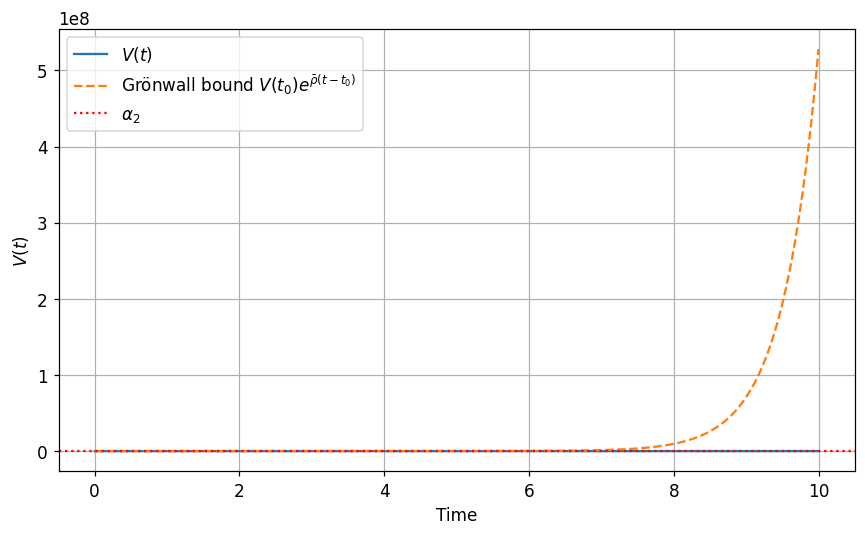

In [14]:
Vt   = np.array([lkf_value(ac["z"], kk, tau_sin2(tgrid[kk])) for kk in range(N)])
lnV  = np.log(np.maximum(Vt, 1e-12))
rho_bar = float(np.max(np.gradient(lnV, dt)[1:]))
bound   = Vt[0]*np.exp(max(rho_bar, 0.0)*tgrid)
alpha1, alpha2 = float(Vt[0]), float(np.max(Vt)*1.15)

print(f"V(t0)      = {Vt[0]:.4f}")
print(f"max V(t)   = {np.max(Vt):.4f}")
print(f"rho_bar    = {rho_bar:.4f}")
print(f"alpha1     = {alpha1:.4f}")
print(f"alpha2     = {alpha2:.4f}")
print(f"finite-time bounded (max V < alpha2): {np.max(Vt) < alpha2}")
print(f"transfer time t_f (first F>=0.95)   : {reach_time(ac['fid']):.3f}  <  T = {T}")

np.savez(os.path.join(RESULTS_DIR, "finite_time.npz"),
         t=tgrid, V=Vt, bound=bound, alpha1=alpha1, alpha2=alpha2, rho_bar=rho_bar)

plt.figure(figsize=(8,5))
plt.plot(tgrid, Vt, label=r'$V(t)$')
plt.plot(tgrid, bound, '--', label=r'Grönwall bound $V(t_0)e^{\bar\rho(t-t_0)}$')
plt.axhline(alpha2, color='r', ls=':', label=r'$\alpha_2$')
plt.xlabel("Time"); plt.ylabel(r'$V(t)$'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR,"plot15_finite_time.png"),
                                dpi=300, bbox_inches="tight"); plt.show()

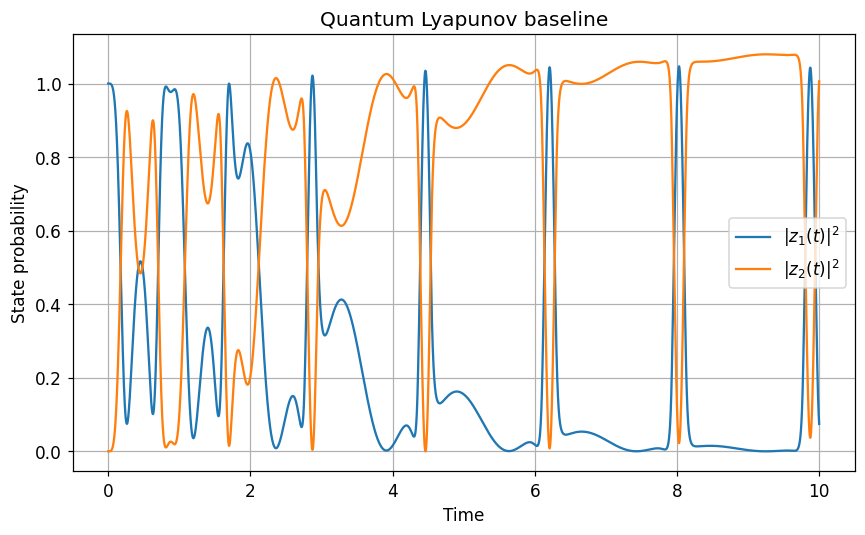

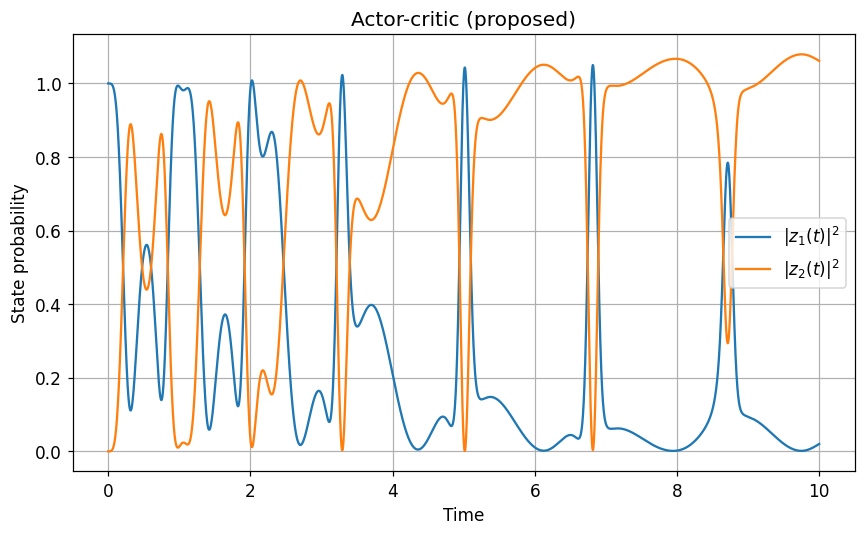

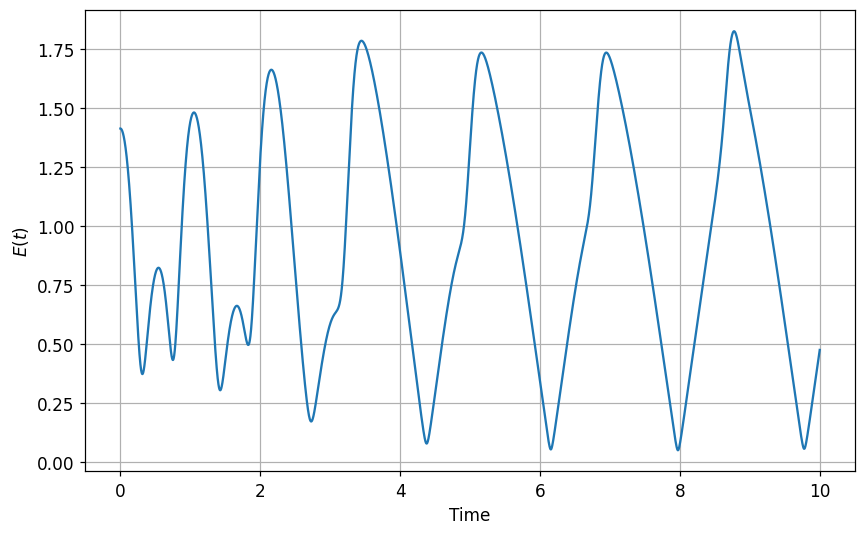

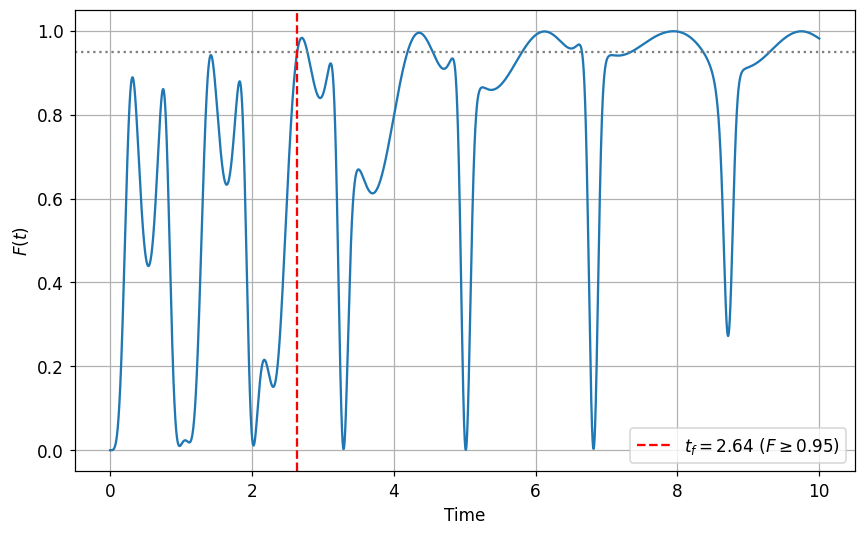

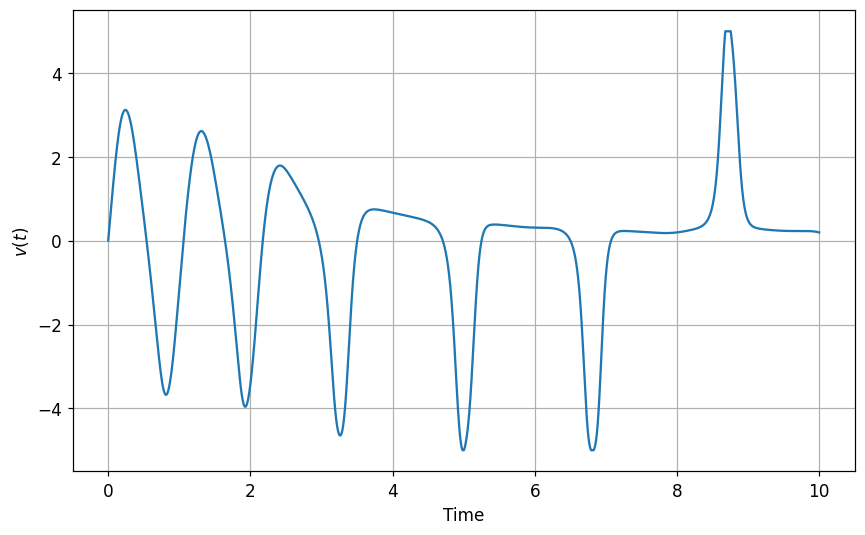

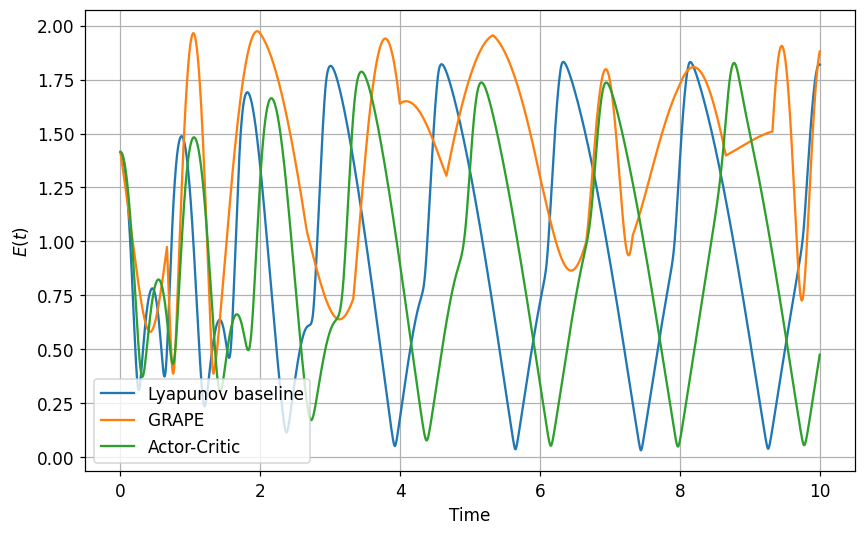

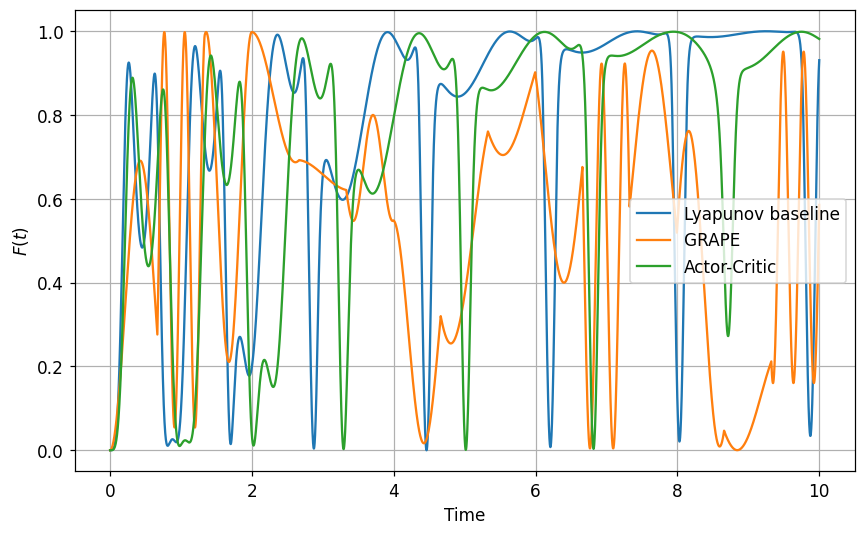

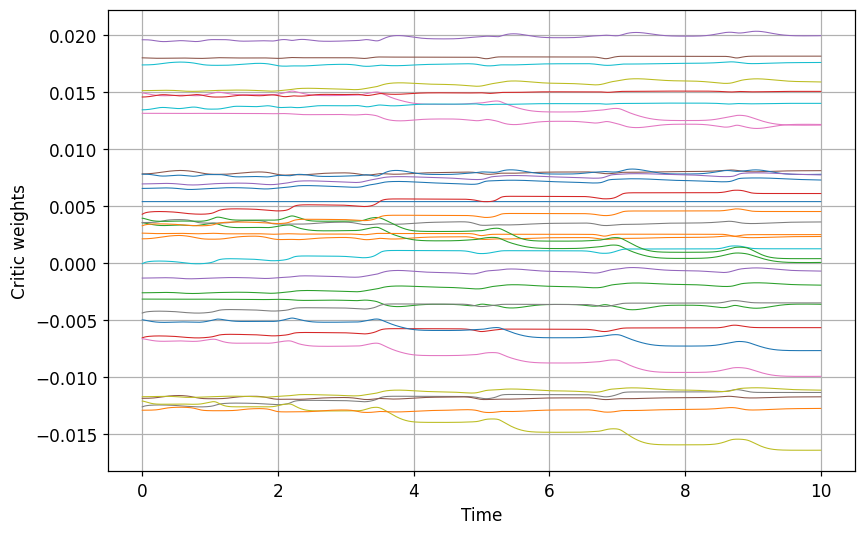

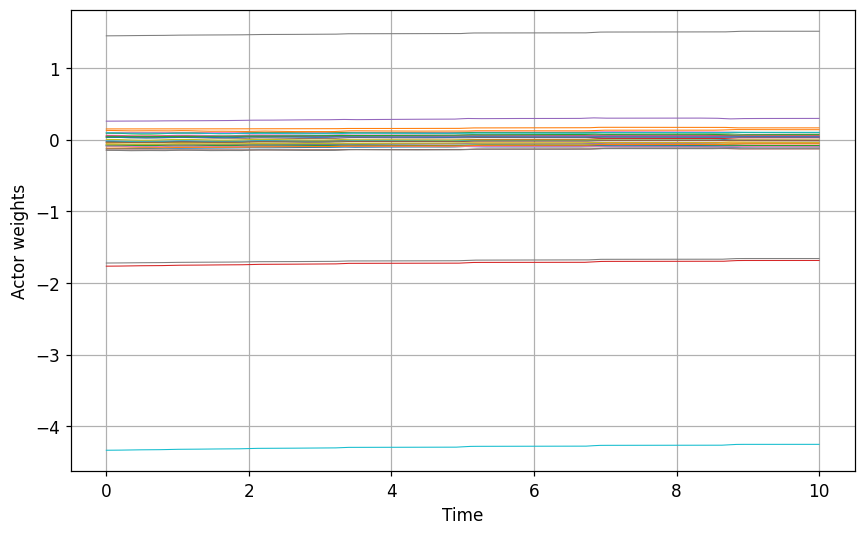

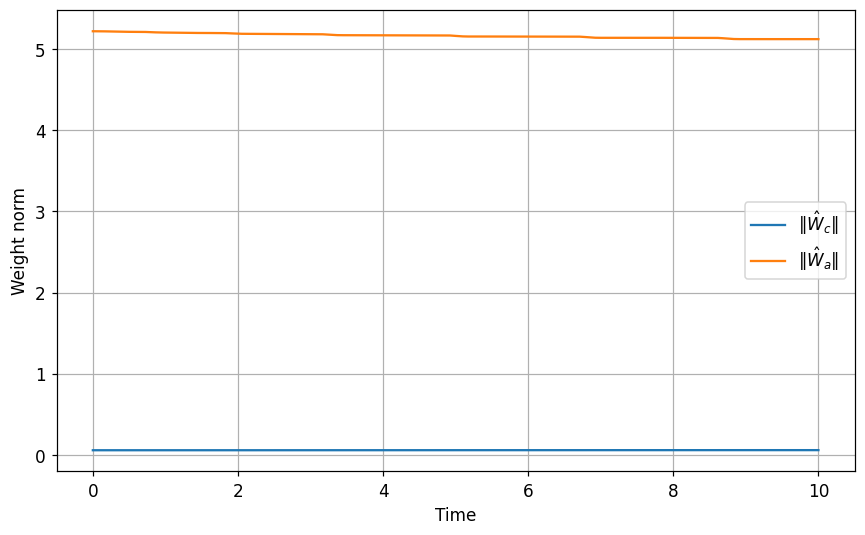

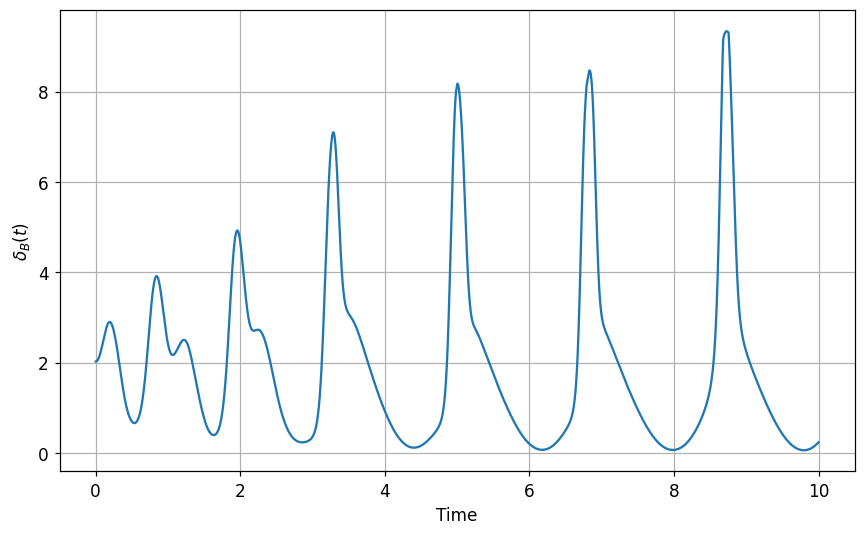

In [15]:
def savefig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, name), dpi=300, bbox_inches="tight")
    plt.show()


for res, ttl, fn in [(lyap, "Quantum Lyapunov baseline", "plot1_baseline_states.png"),
                     (ac,   "Actor-critic (proposed)",   "plot3_ac_states.png")]:
    plt.figure(figsize=(8,5))
    plt.plot(tgrid, np.abs(res["z"][:,0])**2, label=r'$|z_1(t)|^2$')
    plt.plot(tgrid, np.abs(res["z"][:,1])**2, label=r'$|z_2(t)|^2$')
    plt.xlabel("Time"); plt.ylabel("State probability"); plt.title(ttl)
    plt.legend(); plt.grid(True); savefig(fn)

plt.figure(figsize=(8,5)); plt.plot(tgrid, ac["err"])
plt.xlabel("Time"); plt.ylabel(r'$E(t)$'); plt.grid(True); savefig("plot4_tracking_error.png")

tf = reach_time(ac["fid"])
plt.figure(figsize=(8,5)); plt.plot(tgrid, ac["fid"])
if not np.isnan(tf):
    plt.axvline(tf, color='r', ls='--', label=fr'$t_f={tf:.2f}$ ($F\geq0.95$)')
    plt.axhline(0.95, color='gray', ls=':'); plt.legend()
plt.xlabel("Time"); plt.ylabel(r'$F(t)$'); plt.grid(True); savefig("plot5_fidelity.png")

plt.figure(figsize=(8,5)); plt.plot(tgrid, ac["u"])
plt.xlabel("Time"); plt.ylabel(r'$v(t)$'); plt.grid(True); savefig("plot6_control_signal.png")


plt.figure(figsize=(8,5))
plt.plot(tgrid, lyap["err"],  label="Lyapunov baseline")
plt.plot(tgrid, grape["err"], label="GRAPE")
plt.plot(tgrid, ac["err"],    label="Actor-Critic")
plt.xlabel("Time"); plt.ylabel(r'$E(t)$'); plt.legend(); plt.grid(True)
savefig("plot13_error_comparison.png")

plt.figure(figsize=(8,5))
plt.plot(tgrid, lyap["fid"],  label="Lyapunov baseline")
plt.plot(tgrid, grape["fid"], label="GRAPE")
plt.plot(tgrid, ac["fid"],    label="Actor-Critic")
plt.xlabel("Time"); plt.ylabel(r'$F(t)$'); plt.legend(); plt.grid(True)
savefig("plot14_fidelity_comparison.png")


plt.figure(figsize=(8,5))
for i in range(NB): plt.plot(tgrid, ac["Wc_hist"][:,i], lw=0.7)
plt.xlabel("Time"); plt.ylabel("Critic weights"); plt.grid(True); savefig("plot9_critic_weights.png")

plt.figure(figsize=(8,5))
for i in range(NB): plt.plot(tgrid, ac["Wa_hist"][:,i], lw=0.7)
plt.xlabel("Time"); plt.ylabel("Actor weights"); plt.grid(True); savefig("plot10_actor_weights.png")

plt.figure(figsize=(8,5))
plt.plot(tgrid, ac["Wc_norm"], label=r'$\|\hat W_c\|$')
plt.plot(tgrid, ac["Wa_norm"], label=r'$\|\hat W_a\|$')
plt.xlabel("Time"); plt.ylabel("Weight norm"); plt.legend(); plt.grid(True)
savefig("plot16_weight_norms.png")

plt.figure(figsize=(8,5)); plt.plot(tgrid, ac["bellman"])
plt.xlabel("Time"); plt.ylabel(r'$\delta_B(t)$'); plt.grid(True); savefig("plot11_bellman_residual.png")

In [16]:
t0 = time.time()
stat = {"err":[], "fid":[], "energy":[], "tf":[]}
for s in range(N_SEEDS):
    r = simulate_actor_critic(seed=s)
    stat["err"].append(r["err"][-1]);      stat["fid"].append(r["fid"][-1])
    stat["energy"].append(r["energy"][-1]); stat["tf"].append(settling_time(r["fid"]))
    if (s+1) % 5 == 0 or s == N_SEEDS-1:
        print(f"  seed {s+1}/{N_SEEDS} done")

stat_df = pd.DataFrame({
    "Metric": ["Final Tracking Error", "Final Fidelity", "Final Control Energy", "Settling Time"],
    "Mean":   [np.nanmean(stat[k]) for k in ["err","fid","energy","tf"]],
    "Std":    [np.nanstd(stat[k])  for k in ["err","fid","energy","tf"]]})
stat_df.to_csv(os.path.join(RESULTS_DIR, "statistics.csv"), index=False)
print(f"\nelapsed: {time.time()-t0:.1f} s\n")
print(f"=== STATISTICS over {N_SEEDS} seeds ===")
print(stat_df.to_string(index=False))

  seed 5/30 done
  seed 10/30 done
  seed 15/30 done
  seed 20/30 done
  seed 25/30 done
  seed 30/30 done

elapsed: 62.0 s

=== STATISTICS over 30 seeds ===
              Metric      Mean      Std
Final Tracking Error  0.372881 0.291890
      Final Fidelity  0.973565 0.107443
Final Control Energy 33.427311 0.299939
       Settling Time  9.021414 0.211231


sweeping tmax ...
 tmax  Final Fidelity  Final Tracking Error  Final Control Energy  Settling Time
 0.02        0.983187              0.513536             33.366512          8.870
 0.05        0.980451              0.497060             33.511847          9.189
 0.08        0.981488              0.475465             33.366489          9.304
 0.12        0.983104              0.470887             33.171233          9.278
 0.16        0.983300              0.502780             33.026637          9.221 

sweeping R ...
   R  Final Fidelity  Final Tracking Error  Final Control Energy  Settling Time
0.05        0.981135              0.517095             33.288668          9.313
0.10        0.981371              0.491050             33.338368          9.308
0.25        0.981488              0.475465             33.366489          9.304
0.50        0.981522              0.470290             33.375661          9.303
1.00        0.981538              0.467708             33.380215          9.302

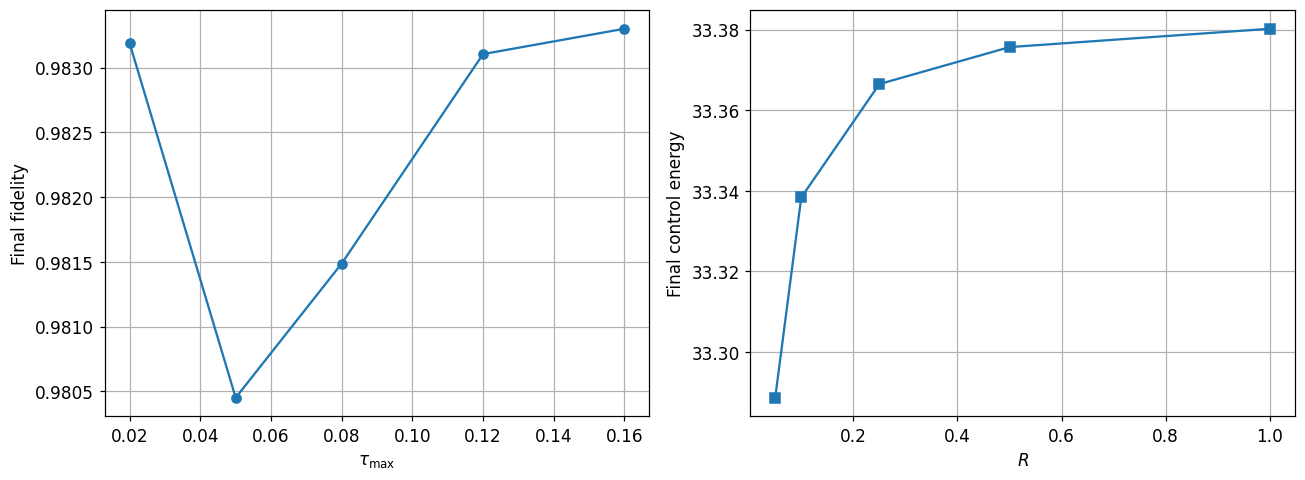

In [17]:
def sweep(param, values, base):
    rows = []
    for val in values:
        kw = dict(base); kw[param] = val
        r  = simulate_actor_critic(**kw)
        rows.append([val, r["fid"][-1], r["err"][-1], r["energy"][-1], settling_time(r["fid"])])
    return pd.DataFrame(rows, columns=[param, "Final Fidelity", "Final Tracking Error",
                                       "Final Control Energy", "Settling Time"])

base_kw = dict(tau_func=tau_sin2, R=R_DEFAULT, gamma_c=0.02, gamma_a=0.015, seed=0)
grids = {"tmax":    [0.02, 0.05, 0.08, 0.12, 0.16],
         "R":       [0.05, 0.10, 0.25, 0.50, 1.00],
         "gamma_c": [0.005, 0.01, 0.02, 0.04, 0.08],
         "gamma_a": [0.005, 0.01, 0.015, 0.03, 0.06]}

t0 = time.time(); sens = {}
for p, g in grids.items():
    print(f"sweeping {p} ...")
    sens[p] = sweep(p, g, base_kw)
    sens[p].to_csv(os.path.join(RESULTS_DIR, f"sensitivity_{p}.csv"), index=False)
    print(sens[p].to_string(index=False), "\n")
print(f"elapsed: {time.time()-t0:.1f} s")

fig, ax = plt.subplots(1, 2, figsize=(12,4.5))
ax[0].plot(sens["tmax"]["tmax"], sens["tmax"]["Final Fidelity"], 'o-')
ax[0].set_xlabel(r'$\tau_{\max}$'); ax[0].set_ylabel("Final fidelity"); ax[0].grid(True)
ax[1].plot(sens["R"]["R"], sens["R"]["Final Control Energy"], 's-')
ax[1].set_xlabel(r'$R$'); ax[1].set_ylabel("Final control energy"); ax[1].grid(True)
plt.tight_layout(); plt.savefig(os.path.join(RESULTS_DIR,"plot17_sensitivity.png"),
                                dpi=300, bbox_inches="tight"); plt.show()

In [18]:
rows = []
for name, fn in DELAY_PROFILES.items():
    print(f"running delay profile '{name}' ...")
    r = simulate_actor_critic(tau_func=fn, seed=0)
    rows.append([name, r["fid"][-1], r["err"][-1], r["energy"][-1], settling_time(r["fid"])])

delay_df = pd.DataFrame(rows, columns=["Delay profile", "Final Fidelity",
                                       "Final Tracking Error", "Final Control Energy",
                                       "Settling Time"])
delay_df.to_csv(os.path.join(RESULTS_DIR, "delay_profiles.csv"), index=False)
print("\n=== DELAY PROFILES ===")
print(delay_df.to_string(index=False))

running delay profile 'sin2' ...
running delay profile 'const' ...
running delay profile 'ramp' ...

=== DELAY PROFILES ===
Delay profile  Final Fidelity  Final Tracking Error  Final Control Energy  Settling Time
         sin2        0.981488              0.475465             33.366489          9.304
        const        0.947970              0.877858             33.274052            NaN
         ramp        0.973063              0.571090             33.392146          9.294


In [19]:
print("="*74)
print("MAIN COMPARISON (Table 1)")
print("="*74)
print(main_table.to_string(index=False))
print()
print("="*74)
print("FINITE-TIME VERIFICATION")
print("="*74)
print(f"V(t0) = {Vt[0]:.4f}   max V = {np.max(Vt):.4f}   rho_bar = {rho_bar:.4f}")
print(f"alpha1 = {alpha1:.4f}   alpha2 = {alpha2:.4f}   FTB satisfied = {np.max(Vt) < alpha2}")
print(f"transfer time t_f = {reach_time(ac['fid']):.3f} < T = {T}")
print()
print("="*74)
print("FILES WRITTEN TO:", os.path.abspath(RESULTS_DIR))
print("="*74)
for f in sorted(os.listdir(RESULTS_DIR)):
    print("   ", f)

MAIN COMPARISON (Table 1)
                       Method  Final Tracking Error  Final Fidelity  Final Infidelity  Final Control Energy  Max State Norm  Transfer Time (F>=0.95)  Mean |Bellman|
Lyapunov baseline (high gain)              1.818868        0.930868          0.069132             45.623665        1.080645                    1.177             NaN
            GRAPE (open-loop)              1.880089        0.585480          0.414520             59.274856        1.080918                    0.743             NaN
      Actor-Critic (proposed)              0.475465        0.981488          0.018512             33.366489        1.081395                    2.639        1.907875

FINITE-TIME VERIFICATION
V(t0) = 1.0000   max V = 1.4122   rho_bar = 2.0085
alpha1 = 1.0000   alpha2 = 1.6241   FTB satisfied = True
transfer time t_f = 2.639 < T = 10.0

FILES WRITTEN TO: C:\Users\vijay\PC Python files\FTSY and OC for QTDS\July 2026\simulation_results_final
    delay_profiles.csv
    finite_tim